<center><h1><strong> 1. Permutation Importance

In [1]:
import pandas as pd
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt
from tqdm import tqdm
import pickle
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
import warnings

warnings.filterwarnings('error')
warnings.filterwarnings('ignore')

In [2]:
file_path = '../../../data/data_for_final_models/AgglomerativeClustering_generated_features.csv'
data = pd.read_csv(file_path)

X = data.drop(columns='Cluster')
y = data['Cluster']

In [3]:
catboost_model = CatBoostClassifier()
catboost_model.load_model('../../../models/1_default_models/catboost_model.cb')

with open('../../../models/1_default_models/lr_model.pkl', 'rb') as f:
    lr_model = pickle.load(f)

with open('../../../models/1_default_models/rf_model.pkl', 'rb') as f:
    rf_model = pickle.load(f)

with open('../../../models/1_default_models/et_model.pkl', 'rb') as f:
    et_model = pickle.load(f)

with open('../../../models/1_default_models/gb_model.pkl', 'rb') as f:
    gb_model = pickle.load(f)

with open('../../../models/1_default_models/meta_model.pkl', 'rb') as f:
    meta_model = pickle.load(f)

In [4]:
catboost_final_preds = catboost_model.predict(X)
lr_final_preds = lr_model.predict(X)
rf_final_preds = rf_model.predict(X)
et_final_preds = et_model.predict(X)
gb_final_preds = gb_model.predict(X)

In [5]:
X_meta_test = pd.DataFrame({
    'catboost': catboost_final_preds.ravel(),
    'lr': lr_final_preds,
    'rf': rf_final_preds,
    'et': et_final_preds,
    'gb': gb_final_preds
})

In [6]:
final_preds = meta_model.predict(X_meta_test)

In [7]:
accuracy = balanced_accuracy_score(y, final_preds)
print(f'Accuracy: {accuracy:.4f}')

Accuracy: 0.9992


In [8]:
base_models = {
    'catboost': catboost_model,
    'lr': lr_model,
    'rf': rf_model,
    'et': et_model,
    'gb': gb_model
}

In [9]:
feature_importances = {}

for model_name, model in tqdm(base_models.items()):
    # Среднее Permutation Importance для каждой модели
    perm_importance = permutation_importance(
        model, X, y, scoring='balanced_accuracy', n_repeats=5, random_state=42
    )
    feature_importances[model_name] = perm_importance.importances_mean

100%|██████████| 5/5 [4:26:54<00:00, 3202.89s/it]  


In [10]:
feature_importance_df = pd.DataFrame(feature_importances, index=X.columns)
feature_importance_df['mean_importance'] = feature_importance_df.mean(axis=1) # считаем среднее важности признака

sorted_importance = feature_importance_df.sort_values(by='mean_importance', ascending=False)

In [11]:
zero_importance_features = sorted_importance[sorted_importance['mean_importance'] == 0].copy()

print(f"Количество признаков с нулевой важностью: {len(zero_importance_features)}")

Количество признаков с нулевой важностью: 2669


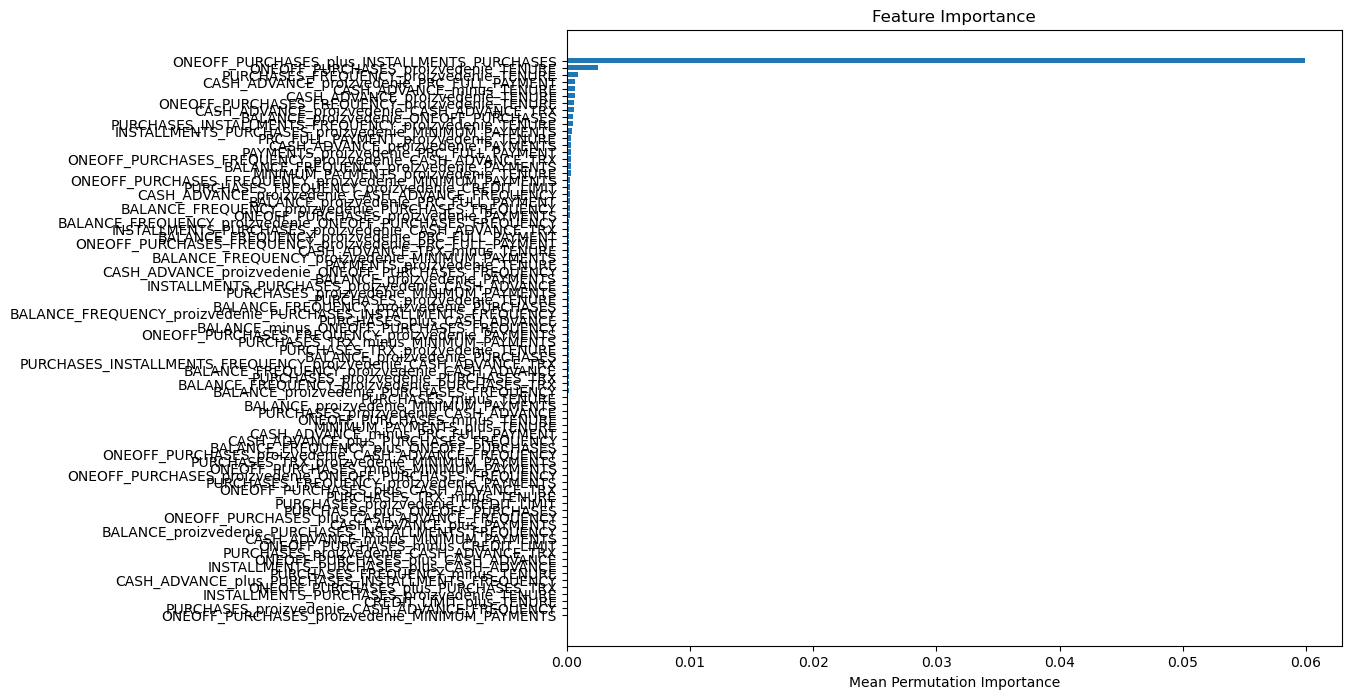

In [12]:
df = sorted_importance[sorted_importance['mean_importance'] >= 0.0001].copy()

plt.figure(figsize=(10, 8))
plt.barh(df.index, df['mean_importance'], align='center')
plt.xlabel('Mean Permutation Importance')
plt.title('Feature Importance')
plt.gca().invert_yaxis()
plt.show()

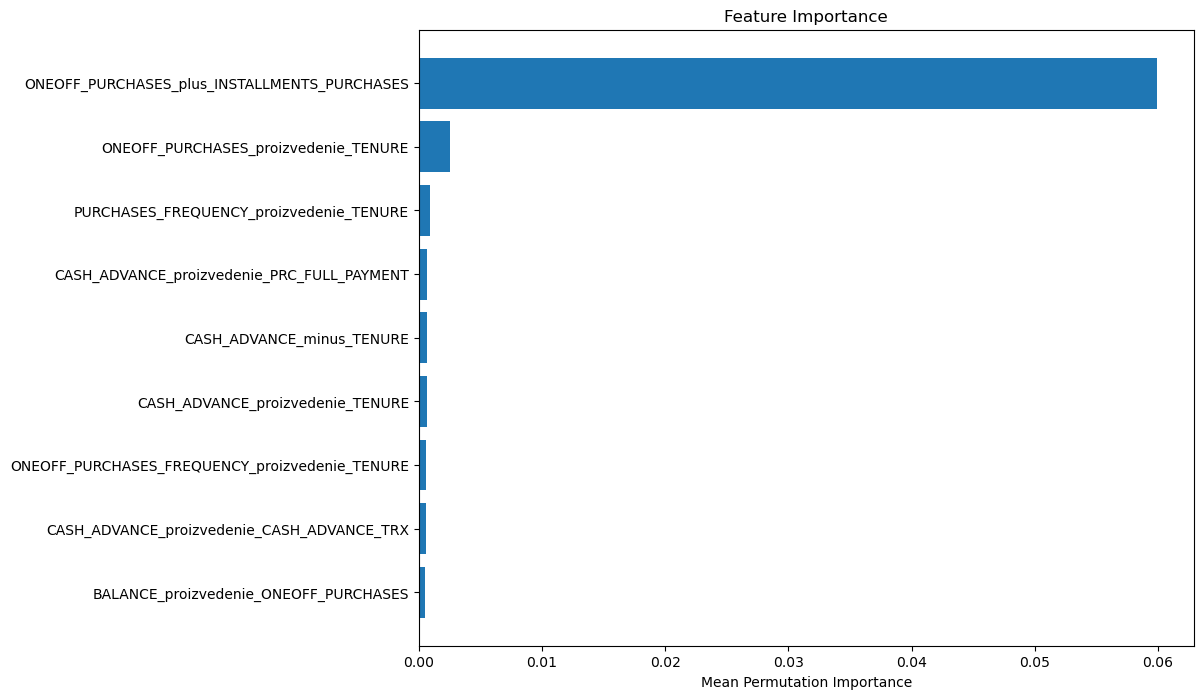

In [16]:
df = sorted_importance[sorted_importance['mean_importance'] >= 0.0005].copy()

plt.figure(figsize=(10, 8))
plt.barh(df.index, df['mean_importance'], align='center')
plt.xlabel('Mean Permutation Importance')
plt.title('Feature Importance')
plt.gca().invert_yaxis()
plt.show()

### Уберем худшие признаки с помощью Permutation importance и посмотрим на точность

In [14]:
important_features = sorted_importance[sorted_importance['mean_importance'] > 0].index.values

X_train, X_test, y_train, y_test = train_test_split(
    data[important_features], y, test_size=0.2, random_state=42
)

catboost_model.fit(X_train, y_train)
lr_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
et_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)

catboost_preds_test = catboost_model.predict(X_test)
lr_preds_test = lr_model.predict(X_test)
rf_preds_test = rf_model.predict(X_test)
et_preds_test = et_model.predict(X_test)
gb_preds_test = gb_model.predict(X_test)

X_meta_test = pd.DataFrame({
    'catboost': catboost_preds_test.ravel(),
    'lr': lr_preds_test,
    'rf': rf_preds_test,
    'et': et_preds_test,
    'gb': gb_preds_test
})

meta_model.fit(X_meta_test, y_test)

final_preds = meta_model.predict(X_meta_test)

accuracy = balanced_accuracy_score(y_test, final_preds)
print(f'Balanced Accuracy: {accuracy:.4f}')

Balanced Accuracy: 0.9956
